# B.O.S.S. — YOLOv8 Training

**Pipeline:**
1. Setup ambiente e librerie
2. Configurazione globale (modello, classi, percorsi)
3. Verifica struttura dataset (train / valid / test)
4. Generazione `data.yaml` per YOLOv8
5. Statistiche dataset pre-training
6. Training YOLOv8n
7. Esportazione modello (ONNX)

---
**Dataset:** `obstacle-detection-dataset` (Kaggle, già in formato YOLO).
**Nota:** La valutazione quantitativa è gestita separatamente in `boss_yolo_test.ipynb`.


In [ ]:
import os, shutil
from pathlib import Path

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None

if IS_KAGGLE:
    WORK_DIR = Path("/kaggle/working")
    os.chdir(WORK_DIR)
    print("Kaggle. Working dir:", os.getcwd())
    print("Input disponibili:", list(Path("/kaggle/input").iterdir()))
else:
    print("Ambiente non Kaggle. Cella saltata.")


## Cella 1 — Installazione dipendenze
Eseguire solo la prima volta o in un nuovo ambiente.

In [ ]:
# Su Kaggle torch/torchvision/numpy/opencv sono preinstallati.
# Installa solo le librerie mancanti.
%pip install ultralytics pyyaml tqdm --quiet


## Cella 2 — Import librerie

In [3]:
import os                         # operazioni su file e directory
import shutil                     # copia/spostamento file
import json                       # parsing file JSON generici
import glob                       # ricerca file con pattern
from pathlib import Path          # gestione percorsi cross-platform

import numpy as np                # operazioni su array e calcolo numerico
import pandas as pd               # strutture dati tabellari per metriche
import cv2                        # OpenCV: lettura/scrittura immagini, disegno
from PIL import Image             # Pillow: manipolazione immagini ad alto livello

import matplotlib.pyplot as plt   # grafici 2D (curve, bar chart)
import matplotlib.patches as mpatches  # elementi grafici personalizzati nei plot
import seaborn as sns             # heatmap e grafici statistici (confusion matrix)

from tqdm import tqdm             # barre di avanzamento per loop su dataset

from ultralytics import YOLO      # modello YOLOv8: training, val, predict

import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Cella 3 — Configurazione globale
**Modifica questa cella per cambiare modello, classi o percorsi.**

In [ ]:
# ============================================================
# CONFIGURAZIONE — modifica questi valori per adattare la pipeline
# ============================================================

MODEL_PATH = "yolov8n.pt"

import torch
import yaml

IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
if IS_KAGGLE:
    INPUT_DIR = Path("/kaggle/input")
    BASE_DIR  = Path("/kaggle/working")
else:
    INPUT_DIR = Path(".").resolve()
    BASE_DIR  = Path(".").resolve()

# ------------------------------------------------------------
# Dataset ROD (formato YOLO, gia splittato in train/valid/test).
# Struttura attesa:
#   <DATASET_ROOT>/
#       train/   (images/ + labels/)
#       valid/   (images/ + labels/)
#       test/    (images/ + labels/)
#   data.yaml
# La fusione con BOSS_GT avviene nella Cella 3b.
# ------------------------------------------------------------
if IS_KAGGLE:
    DATASET_ROOT = Path(
        "/kaggle/input/datasets/abtinzandi/"
        "obstacle-detection-dataset/ROD-Dataset/dataset"
    )
else:
    DATASET_ROOT = BASE_DIR / "Senior-Design-VIAD-4"

TRAIN_DIR = DATASET_ROOT / "train"
VALID_DIR = DATASET_ROOT / "valid"
TEST_DIR  = DATASET_ROOT / "test"

# Directory di lavoro dove verra scritto il data.yaml usato da YOLOv8
DATASET_DIR = BASE_DIR / "dataset_boss"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Class names: si tenta la lettura dinamica dal data.yaml originale del dataset.
# Se assente, si usa un fallback con 26 classi placeholder generiche.
# ------------------------------------------------------------
# Ricerca ricorsiva: trova tutti i data.yaml sotto /kaggle/input
_dataset_yaml_candidates = sorted(Path("/kaggle/input").rglob("data.yaml")) if IS_KAGGLE else [
    DATASET_ROOT / "data.yaml",
    DATASET_ROOT.parent / "data.yaml",
]
_loaded_yaml = None
for _yp in _dataset_yaml_candidates:
    if _yp.exists():
        with open(_yp) as _f:
            _loaded_yaml = yaml.safe_load(_f)
        print(f"Letto data.yaml originale: {_yp}")
        break

if _loaded_yaml is not None and "names" in _loaded_yaml:
    _names = _loaded_yaml["names"]
    if isinstance(_names, dict):
        # YOLOv8 formato dict: {0: 'classA', 1: 'classB', ...}
        BOSS_CLASSES = [_names[k] for k in sorted(_names.keys(), key=int)]
    else:
        BOSS_CLASSES = list(_names)
else:
    print("data.yaml del dataset non trovato — uso fallback a 26 classi generiche.")
    BOSS_CLASSES = [f"class_{i}" for i in range(26)]

NUM_CLASSES = len(BOSS_CLASSES)

# ------------------------------------------------------------
# Iperparametri di training
# ------------------------------------------------------------
EPOCHS        = 200
BATCH_SIZE    = 64
IMG_SIZE      = 640
LEARNING_RATE = 0.01
DEVICE        = "0,1" if torch.cuda.device_count() >= 2 else ("0" if torch.cuda.is_available() else "cpu")
IOU_THRESHOLD = 0.45

print(f"Modello: {MODEL_PATH}")
print(f"Classi ({NUM_CLASSES}): {BOSS_CLASSES}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")
print(f"GPU disponibili: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"Device: {DEVICE}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"  train: {TRAIN_DIR}")
print(f"  valid: {VALID_DIR}")
print(f"  test:  {TEST_DIR}")


## Cella 3b — Fusione dataset Kaggle + Roboflow con classi in comune

In [ ]:
# ============================================================
# Cella 3b — Fusione dataset ROD + BOSS_GT
#
# Logica:
# 1. Legge entrambi i data.yaml e ricava le due liste di classi
# 2. Calcola l'intersezione (case-insensitive) -> lista classi comune
# 3. Costruisce due mappe: ROD_id->MERGED_id e BOSS_id->MERGED_id
# 4. TRAIN merged = ROD/train (1x) + BOSS/(train+valid+test) replicato DUP volte
#    DUP e' calcolato automaticamente affinche' BOSS pesi ~20% del train.
# 5. VALID merged = ROD/valid ; TEST merged = ROD/test (solo ROD, rimappati)
# 6. Scrive data.yaml unificato e aggiorna yaml_path per il training
# ============================================================

import yaml, shutil
from pathlib import Path
from tqdm import tqdm

# Frazione target del training occupata dalle immagini BOSS (oversampling)
BOSS_TARGET_FRACTION = 0.20

# --- Paths ---
ROD_YAML  = Path("/kaggle/input/datasets/abtinzandi/obstacle-detection-dataset/ROD-Dataset/dataset/data.yaml") \
            if IS_KAGGLE else DATASET_ROOT / "data.yaml"
BOSS_ROOT = Path("/kaggle/input/datasets/lorenzoverdura/boss-recordings1/rf_split") \
            if IS_KAGGLE else BASE_DIR / "boss-recordings1" / "rf_split"
BOSS_YAML = BOSS_ROOT / "data.yaml"

if not ROD_YAML.exists():
    raise FileNotFoundError(f"data.yaml ROD non trovato: {ROD_YAML}")
if not BOSS_YAML.exists():
    raise FileNotFoundError(f"data.yaml BOSS non trovato: {BOSS_YAML}")

def _read_names(yaml_path):
    with open(yaml_path) as f:
        d = yaml.safe_load(f)
    names = d["names"]
    if isinstance(names, dict):
        return [names[k] for k in sorted(names.keys(), key=int)]
    return list(names)

ROD_CLASSES  = _read_names(ROD_YAML)
BOSS_CLS_RAW = _read_names(BOSS_YAML)

print(f"Classi ROD  ({len(ROD_CLASSES)}): {ROD_CLASSES}")
print(f"Classi BOSS ({len(BOSS_CLS_RAW)}): {BOSS_CLS_RAW}")

# --- Intersezione: mantieni solo classi presenti in entrambi (case-insensitive) ---
boss_lower = {n.lower().strip(): n for n in BOSS_CLS_RAW}
rod_lower  = {n.lower().strip(): n for n in ROD_CLASSES}

# Lista classi comuni nell'ordine del dataset ROD (piu' grande, e' il principale)
MERGED_CLASSES = [n for n in ROD_CLASSES if n.lower().strip() in boss_lower]

rod_only  = [n for n in ROD_CLASSES  if n.lower().strip() not in boss_lower]
boss_only = [n for n in BOSS_CLS_RAW if n.lower().strip() not in rod_lower]
print(f"\nClassi in comune ({len(MERGED_CLASSES)}): {MERGED_CLASSES}")
print(f"Scartate solo-ROD ({len(rod_only)}): {rod_only}")
print(f"Scartate solo-BOSS ({len(boss_only)}): {boss_only}")

# Aggiorna variabili globali usate dalle celle successive
BOSS_CLASSES = MERGED_CLASSES
NUM_CLASSES  = len(BOSS_CLASSES)

# Mappa: old_id -> new_id per ciascun dataset
MERGED_NAME_TO_ID = {n.lower().strip(): i for i, n in enumerate(MERGED_CLASSES)}

ROD_TO_MERGED  = {i: MERGED_NAME_TO_ID[n.lower().strip()]
                  for i, n in enumerate(ROD_CLASSES)
                  if n.lower().strip() in MERGED_NAME_TO_ID}
BOSS_TO_MERGED = {i: MERGED_NAME_TO_ID[n.lower().strip()]
                  for i, n in enumerate(BOSS_CLS_RAW)
                  if n.lower().strip() in MERGED_NAME_TO_ID}

print(f"\nMappa ROD->Merged:  {ROD_TO_MERGED}")
print(f"Mappa BOSS->Merged: {BOSS_TO_MERGED}")

# --- Cartelle di output ---
MERGED_DIR     = BASE_DIR / "dataset_merged"
M_TRAIN_IMGS   = MERGED_DIR / "train" / "images"
M_TRAIN_LBLS   = MERGED_DIR / "train" / "labels"
M_VALID_IMGS   = MERGED_DIR / "valid" / "images"
M_VALID_LBLS   = MERGED_DIR / "valid" / "labels"
M_TEST_IMGS    = MERGED_DIR / "test"  / "images"
M_TEST_LBLS    = MERGED_DIR / "test"  / "labels"
# Pulizia per evitare residui di run precedenti
if MERGED_DIR.exists():
    shutil.rmtree(MERGED_DIR)
for d in (M_TRAIN_IMGS, M_TRAIN_LBLS, M_VALID_IMGS, M_VALID_LBLS, M_TEST_IMGS, M_TEST_LBLS):
    d.mkdir(parents=True, exist_ok=True)

IMG_EXTS = ("*.jpg", "*.jpeg", "*.png", "*.bmp")

def _list_images(img_dir):
    files = []
    for ext in IMG_EXTS:
        files += list(img_dir.glob(ext))
    return files

def copy_split(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir, id_map, prefix, dup=1):
    """Copia immagini+label rimappati. Replica dup volte con stem univoco.
    Le righe con classi non presenti nella mappa vengono scartate."""
    kept = dropped = imgs = 0
    img_files = _list_images(src_img_dir)
    for d in range(dup):
        for img in img_files:
            lf = src_lbl_dir / (img.stem + ".txt")
            stem = f"{prefix}_{img.stem}" if dup == 1 else f"{prefix}_d{d}_{img.stem}"
            shutil.copy(img, dst_img_dir / (stem + img.suffix))
            imgs += 1
            out_lines = []
            if lf.exists():
                for line in lf.read_text().strip().splitlines():
                    parts = line.strip().split()
                    if not parts:
                        continue
                    old_id = int(parts[0])
                    if old_id in id_map:
                        parts[0] = str(id_map[old_id])
                        out_lines.append(" ".join(parts))
                        kept += 1
                    else:
                        dropped += 1
            (dst_lbl_dir / (stem + ".txt")).write_text("\n".join(out_lines))
    return imgs, kept, dropped

# --- Conteggio per calcolare il fattore di oversampling DUP ---
rod_train_imgs = len(_list_images(TRAIN_DIR / "images"))
BOSS_SPLITS = [BOSS_ROOT / s for s in ("train", "valid", "test")]
boss_total_imgs = sum(len(_list_images(sp / "images")) for sp in BOSS_SPLITS if (sp / "images").exists())

if boss_total_imgs == 0:
    raise FileNotFoundError(f"Nessuna immagine BOSS trovata sotto {BOSS_ROOT}")

# DUP t.c. boss*DUP / (rod + boss*DUP) ~= BOSS_TARGET_FRACTION
target = BOSS_TARGET_FRACTION
DUP = max(1, round((target / (1 - target)) * rod_train_imgs / boss_total_imgs))
print(f"\nROD train: {rod_train_imgs} img | BOSS totale (train+valid+test): {boss_total_imgs} img")
print(f"Fattore oversampling BOSS: DUP={DUP} (target ~{int(target*100)}% del train)")

# --- TRAIN: ROD/train (1x) + BOSS tutti gli split (DUP x) ---
print("\n[TRAIN]")
n, k, d = copy_split(TRAIN_DIR / "images", TRAIN_DIR / "labels",
                     M_TRAIN_IMGS, M_TRAIN_LBLS, ROD_TO_MERGED, "rod")
print(f"  ROD/train  -> {n} img | {k} righe label, {d} scartate")
for sp in BOSS_SPLITS:
    if not (sp / "images").exists():
        continue
    n, k, d = copy_split(sp / "images", sp / "labels",
                         M_TRAIN_IMGS, M_TRAIN_LBLS, BOSS_TO_MERGED, f"boss_{sp.name}", dup=DUP)
    print(f"  BOSS/{sp.name} x{DUP} -> {n} img | {k} righe label, {d} scartate")

# --- VALID: solo ROD ---
print("\n[VALID]")
n, k, d = copy_split(VALID_DIR / "images", VALID_DIR / "labels",
                     M_VALID_IMGS, M_VALID_LBLS, ROD_TO_MERGED, "rod")
print(f"  ROD/valid -> {n} img | {k} righe label, {d} scartate")

# --- TEST: solo ROD ---
print("\n[TEST]")
n, k, d = copy_split(TEST_DIR / "images", TEST_DIR / "labels",
                     M_TEST_IMGS, M_TEST_LBLS, ROD_TO_MERGED, "rod")
print(f"  ROD/test  -> {n} img | {k} righe label, {d} scartate")

# --- data.yaml unificato ---
merged_data_yaml = {
    "path":  str(MERGED_DIR),
    "train": "train/images",
    "val":   "valid/images",
    "test":  "test/images",
    "nc":    NUM_CLASSES,
    "names": BOSS_CLASSES,
}
yaml_path = MERGED_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(merged_data_yaml, f, default_flow_style=False, allow_unicode=True)

# Aggiorna TRAIN_DIR/VALID_DIR/TEST_DIR per le celle successive
TRAIN_DIR = M_TRAIN_IMGS.parent
VALID_DIR = M_VALID_IMGS.parent
TEST_DIR  = M_TEST_IMGS.parent

n_train = len(_list_images(M_TRAIN_IMGS))
n_boss  = boss_total_imgs * DUP
print(f"\ndata.yaml unificato: {yaml_path}")
print(f"Classi ({NUM_CLASSES}): {BOSS_CLASSES}")
print(f"Train images: {n_train}  (di cui BOSS ~{n_boss}, {100*n_boss/max(1,n_train):.1f}%)")
print(f"Valid images: {len(_list_images(M_VALID_IMGS))}")
print(f"Test  images: {len(_list_images(M_TEST_IMGS))}")


## Cella 4 — Verifica struttura dataset

**Su Kaggle:** il dataset `Senior-Design-VIAD-4` è già estratto in `/kaggle/input/...`.
Si verifica la presenza delle tre cartelle `train/`, `valid/`, `test/` e si conta il numero di immagini e label per ciascuna.


In [6]:
# Verifica dell'integrità strutturale del dataset.
# YOLOv8 si aspetta immagini e label nella stessa cartella (o in sottocartelle
# parallele `images/` e `labels/`). Il dataset VIAD-4 mette tutto nella stessa
# directory split (train/, valid/, test/), per cui si conteggiano direttamente
# i file per estensione.

IMG_EXTS   = {".jpg", ".jpeg", ".png", ".bmp"}
LABEL_EXT  = ".txt"

def _count_dataset_split(split_dir: Path):
    if not split_dir.exists():
        return None
    # Cerca prima in <split>/images e <split>/labels (struttura "esplicita")
    img_dir = split_dir / "images"
    lbl_dir = split_dir / "labels"
    if img_dir.exists() and lbl_dir.exists():
        images = [p for p in img_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
        labels = list(lbl_dir.rglob(f"*{LABEL_EXT}"))
        return {"images": len(images), "labels": len(labels),
                "img_dir": img_dir, "lbl_dir": lbl_dir}
    # Altrimenti: immagini e label mescolate nella stessa cartella
    images = [p for p in split_dir.rglob("*") if p.suffix.lower() in IMG_EXTS]
    labels = list(split_dir.rglob(f"*{LABEL_EXT}"))
    return {"images": len(images), "labels": len(labels),
            "img_dir": split_dir, "lbl_dir": split_dir}

for name, sd in [("train", TRAIN_DIR), ("valid", VALID_DIR), ("test", TEST_DIR)]:
    info = _count_dataset_split(sd)
    if info is None:
        print(f"MANCANTE  {name}: {sd}")
    else:
        print(f"OK  {name}: {sd}")
        print(f"     immagini: {info['images']:>6}  | label: {info['labels']:>6}")
        print(f"     img_dir : {info['img_dir']}")
        print(f"     lbl_dir : {info['lbl_dir']}")


OK  train: /kaggle/working/dataset_merged/train
     immagini:  19243  | label:  19243
     img_dir : /kaggle/working/dataset_merged/train/images
     lbl_dir : /kaggle/working/dataset_merged/train/labels
OK  valid: /kaggle/working/dataset_merged/valid
     immagini:   3511  | label:   3511
     img_dir : /kaggle/working/dataset_merged/valid/images
     lbl_dir : /kaggle/working/dataset_merged/valid/labels
OK  test: /kaggle/working/dataset_merged/test
     immagini:   1629  | label:   1629
     img_dir : /kaggle/working/dataset_merged/test/images
     lbl_dir : /kaggle/working/dataset_merged/test/labels


In [7]:
# DIAGNOSTICA: mostra la struttura effettiva del dataset per verificare
# il formato delle annotazioni (YOLO .txt vs COCO JSON, ecc.)
import subprocess

print("=== Contenuto DATASET_ROOT (primi 2 livelli) ===")
for p in sorted(DATASET_ROOT.rglob("*")):
    depth = len(p.relative_to(DATASET_ROOT).parts)
    if depth <= 2:
        indent = "  " * (depth - 1)
        size = p.stat().st_size if p.is_file() else ""
        print(f"{indent}{p.name}  {'(' + str(size) + ' B)' if size != '' else '[dir]'}")

print("\n=== Estensioni file nel dataset ===")
from collections import Counter
exts = Counter(p.suffix.lower() for p in DATASET_ROOT.rglob("*") if p.is_file())
for ext, count in sorted(exts.items(), key=lambda x: -x[1]):
    print(f"  {ext or '(no ext)':15s}: {count}")


=== Contenuto DATASET_ROOT (primi 2 livelli) ===
class_distribution.csv  (796 B)
data.yaml  (386 B)
images_manifest.csv  (1193764 B)
rename_map.csv  (1928849 B)
test  [dir]
  images  [dir]
  labels  [dir]
train  [dir]
  images  [dir]
  labels  [dir]
valid  [dir]
  images  [dir]
  labels  [dir]

=== Estensioni file nel dataset ===
  .txt           : 24326
  .jpg           : 24326
  .csv           : 3
  .yaml          : 1


## Cella 5 — Creazione file `data.yaml` per YOLOv8


In [8]:
# data.yaml già generato dalla Cella 3b — nessuna azione necessaria.
print(f"yaml_path in uso: {yaml_path}")
print(f"Classi ({NUM_CLASSES}): {BOSS_CLASSES}")


yaml_path in uso: /kaggle/working/dataset_merged/data.yaml
Classi (19): ['Bike', 'Car', 'Person', 'Stairs', 'Traffic sign', 'Electrical Pole', 'Road', 'Motorcycle', 'Dustbin', 'Manhole', 'Tree', 'Pedestrian crosswalk', 'Truck', 'Bench', 'Teraffic Barrel', 'Plant Pot', 'Electrical Box', 'Chair', 'Bicycle Rack']


## Cella 6 — Statistiche dataset pre-training


              Classe  Train  Val  Test  Totale
                Bike    324   95    49     468
                 Car   4563 1003   247    5813
              Person   7660 1033   320    9013
              Stairs   1126  339   223    1688
        Traffic sign    696  114   104     914
     Electrical Pole    599   85    42     726
                Road    565   84    37     686
          Motorcycle    896   82    37    1015
             Dustbin   1378  153    45    1576
             Manhole   1782  480   242    2504
                Tree   1673  293   150    2116
Pedestrian crosswalk   1879  429   189    2497
               Truck    622  159    43     824
               Bench    723   40    28     791
     Teraffic Barrel    541   17    19     577
           Plant Pot    571   37    34     642
      Electrical Box    458   29    34     521
               Chair   1771  419   168    2358
        Bicycle Rack    172   38    36     246


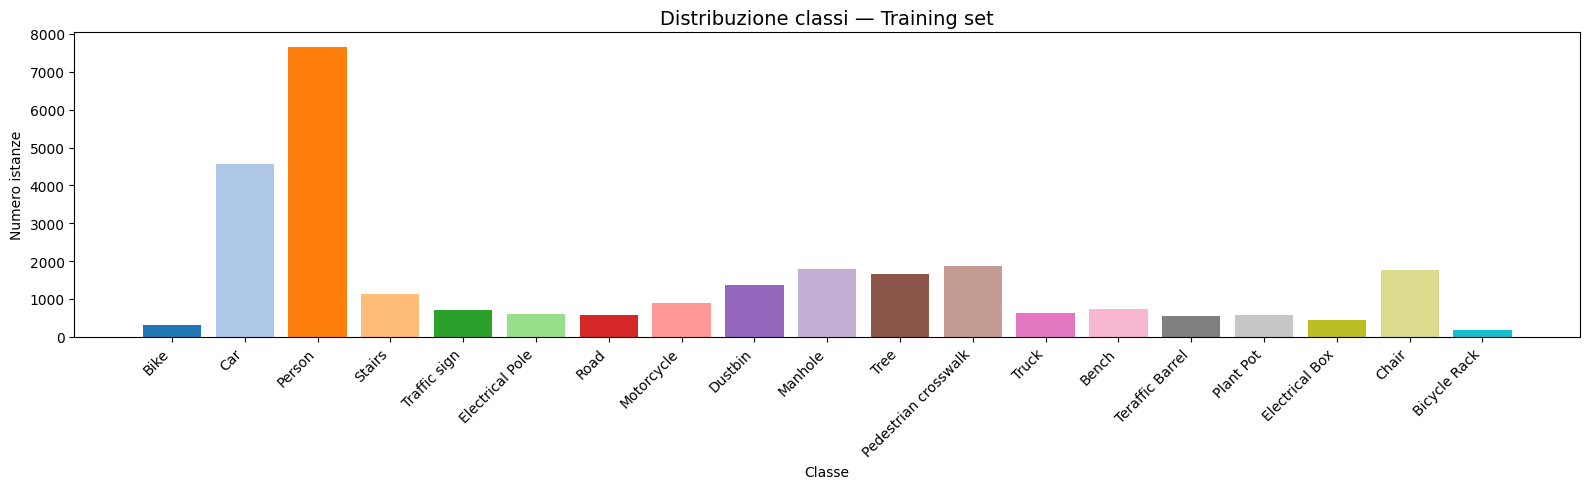

In [9]:
# Analizza la distribuzione delle classi nel dataset prima del training.
# Importante per individuare class imbalance che potrebbe degradare le performance.

def count_class_distribution(split_dir: Path):
    """
    Conta le occorrenze di ogni classe in tutti i file .txt YOLO del split.
    Gestisce sia la struttura piatta (label nella stessa cartella delle immagini)
    sia la struttura `labels/` separata.
    """
    counts = {i: 0 for i in range(NUM_CLASSES)}
    if not split_dir.exists():
        return counts

    lbl_dir = split_dir / "labels" if (split_dir / "labels").exists() else split_dir
    label_files = list(lbl_dir.rglob("*.txt"))

    for lf in label_files:
        try:
            text = lf.read_text().strip()
        except Exception:
            continue
        for line in text.split("\n"):
            line = line.strip()
            if not line:
                continue
            try:
                class_id = int(line.split()[0])
            except (ValueError, IndexError):
                continue
            if class_id in counts:
                counts[class_id] += 1
    return counts


train_counts = count_class_distribution(TRAIN_DIR)
val_counts   = count_class_distribution(VALID_DIR)
test_counts  = count_class_distribution(TEST_DIR)

# Costruisce DataFrame per visualizzazione tabellare
df_dist = pd.DataFrame({
    "Classe": BOSS_CLASSES,
    "Train":  [train_counts[i] for i in range(NUM_CLASSES)],
    "Val":    [val_counts[i]   for i in range(NUM_CLASSES)],
    "Test":   [test_counts[i]  for i in range(NUM_CLASSES)],
})
df_dist["Totale"] = df_dist["Train"] + df_dist["Val"] + df_dist["Test"]

print(df_dist.to_string(index=False))

# Grafico a barre della distribuzione delle classi nel training set
fig, ax = plt.subplots(figsize=(16, 5))
colors = plt.cm.tab20.colors * ((NUM_CLASSES // 20) + 1)
bars = ax.bar(BOSS_CLASSES, df_dist["Train"], color=colors[:NUM_CLASSES])
ax.set_title("Distribuzione classi — Training set", fontsize=14)
ax.set_xlabel("Classe")
ax.set_ylabel("Numero istanze")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(BASE_DIR / "plot_class_distribution.png", dpi=150)
plt.show()


## Cella 7 — Training YOLOv8
Il training salva automaticamente i pesi migliori in `runs/detect/boss_yolo/weights/best.pt`.

In [ ]:
# Fine-tuning del modello YOLOv8 sul dataset fuso ROD + BOSS.
# Tutti i parametri sono configurabili nella cella 3.

# RESUME=False: training nuovo da yolov8n.pt (dataset e classi cambiati).
# RESUME=True: riprende last.pt da un training precedente con LE STESSE classi.
RESUME = False

if IS_KAGGLE and RESUME:
    LAST_PT = Path("/kaggle/input/models/lorenzoverdura/boss-yolo-checkpoint/pytorch/default/8/last.pt")
    print(f"Checkpoint: {LAST_PT} — esiste: {LAST_PT.exists()}")
else:
    LAST_PT = BASE_DIR / "runs/detect/boss_yolo/weights/last.pt"

if RESUME and LAST_PT.exists():
    print(f"Riprendendo training da: {LAST_PT}")
    # Shim di compatibilità: PyTorch 2.x ha rimosso torch._utils._element_size
    # ma i .pt salvati con versioni precedenti lo referenziano via pickle
    import importlib, torch as _torch
    if not hasattr(_torch, "_utils"):
        _torch._utils = importlib.import_module("torch._utils")
    if not hasattr(_torch._utils, "_element_size"):
        _torch._utils._element_size = lambda dtype: _torch.tensor([], dtype=dtype).element_size()
    model = YOLO(str(LAST_PT))
    results_train = model.train(resume=True)
else:
    if RESUME:
        print("ATTENZIONE: last.pt non trovato — controlla di aver aggiunto il model al notebook.")
    model = YOLO(MODEL_PATH)   # carica il modello di partenza (pre-trained su COCO)
    results_train = model.train(
        data      = str(yaml_path),      # file data.yaml con percorsi e classi
        epochs    = EPOCHS,              # numero di epoche di training
        batch     = BATCH_SIZE,          # immagini per batch
        imgsz     = IMG_SIZE,            # risoluzione input (640x640)
        lr0       = LEARNING_RATE,       # learning rate iniziale
        device    = DEVICE,              # GPU/CPU
        name      = "boss_yolo",         # nome cartella di output in runs/detect/
        patience  = 50,                  # early stopping: ferma se val/mAP non migliora per 50 epoche
        save      = True,                # salva best.pt e last.pt dopo ogni epoca
        plots     = True,                # genera grafici training automaticamente
        verbose   = True,
        cache     = False,               # evita scrittura .cache in /kaggle/input (read-only)
    )

# DDP con 2+ GPU restituisce None al processo principale — i pesi sono salvati ugualmente
if results_train is not None:
    BEST_MODEL_PATH = Path(results_train.save_dir) / "weights" / "best.pt"
else:
    BEST_MODEL_PATH = BASE_DIR / "runs/detect/boss_yolo/weights/best.pt"
print(f"Modello migliore: {BEST_MODEL_PATH}")
print(f"Esiste: {BEST_MODEL_PATH.exists()}")

## Cella 7b — Recupero path modello dopo training

In [11]:
import glob as _glob

# Cerca i pesi nella directory di lavoro corrente (BASE_DIR è definito in Cella 3)
found_pts = _glob.glob(str(BASE_DIR / 'runs/detect/**/weights/*.pt'), recursive=True)
for p in sorted(found_pts):
    print(p)

best_candidates = [p for p in found_pts if p.endswith('best.pt')]

if best_candidates:
    BEST_MODEL_PATH = Path(best_candidates[0])
    print(f"\nBEST_MODEL_PATH (da working): {BEST_MODEL_PATH}")
elif IS_KAGGLE:
    # Fallback Kaggle: carica dal dataset con i pesi salvati
    CHECKPOINT_DIR = Path("/kaggle/input/models/lorenzoverdura/boss-yolo-checkpoint/pytorch/default/1")
    best_ckpt = CHECKPOINT_DIR / "best.pt"
    last_ckpt = CHECKPOINT_DIR / "last.pt"

    if best_ckpt.exists():
        BEST_MODEL_PATH = best_ckpt
        print(f"\nBEST_MODEL_PATH (da checkpoint dataset): {BEST_MODEL_PATH}")
    elif last_ckpt.exists():
        BEST_MODEL_PATH = last_ckpt
        print(f"\nBEST_MODEL_PATH (last.pt da checkpoint dataset): {BEST_MODEL_PATH}")
    else:
        raise FileNotFoundError(
            f"Nessun .pt trovato né in working né in {CHECKPOINT_DIR}. "
            "Esegui il training oppure verifica che il dataset boss-yolo-checkpoint sia allegato."
        )
else:
    raise FileNotFoundError(
        f"Nessun .pt trovato in {BASE_DIR / 'runs/detect'}. Esegui il training prima."
    )

/kaggle/working/runs/detect/boss_yolo/weights/best.pt
/kaggle/working/runs/detect/boss_yolo/weights/last.pt

BEST_MODEL_PATH (da working): /kaggle/working/runs/detect/boss_yolo/weights/best.pt


## Cella 8 — Esportazione modello (ONNX)

Esporta `best.pt` in formato **ONNX** per il deployment su dispositivo Edge (Jetson, OpenVINO, ONNX Runtime).

- `simplify=True`: ottimizza il grafo rimuovendo operatori ridondanti
- `opset=12`: compatibile con TensorRT 8+ e la maggior parte dei runtime Edge
- `dynamic=False`: dimensioni fisse per massima ottimizzazione hardware

Il file `.onnx` viene salvato nella stessa cartella di `best.pt`.

In [12]:
# # ============================================================
# # Cella 8 — Esportazione modello in formato ONNX
# # ============================================================
# export_model = YOLO(str(BEST_MODEL_PATH))

# onnx_path = export_model.export(
#     format   = "onnx",
#     imgsz    = IMG_SIZE,
#     dynamic  = False,   # dimensioni input fisse per ottimizzazione hardware
#     simplify = True,    # semplifica il grafo ONNX (rimuove operatori ridondanti)
#     opset    = 12,      # compatibile con TensorRT 8+ e ONNX Runtime
# )

# print(f"Modello esportato: {onnx_path}")